In [1]:
!pip install scipy -q

import os
import numpy as np
import pandas as pd
import scipy.io as sio
import matplotlib.pyplot as plt

from scipy.signal import savgol_filter

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score
)

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from datetime import datetime

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using Device:", device)

Using Device: cuda


In [16]:
mat = sio.loadmat('/content/drive/MyDrive/Oxford_Battery_Degradation_Dataset_1.mat')

all_cells = ['Cell2', 'Cell3', 'Cell5', 'Cell6', 'Cell8']

SEQ_LEN = 10
EPOCHS = 80
BATCH_SIZE = 16

timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")

save_dir = f'/content/drive/MyDrive/TinyML_RUL_{timestamp}'
os.makedirs(save_dir, exist_ok=True)

In [17]:
def extract_cell_data(cell_struct):

    cycle_names = [name for name in cell_struct[0,0].dtype.names if 'cyc' in name]
    cycle_names = sorted(cycle_names)

    all_features = []

    for cyc in cycle_names:

        try:
            cycle_data = cell_struct[0,0][cyc][0,0]
            discharge = cycle_data['C1dc'][0,0]

            t = discharge['t'].flatten()
            v = discharge['v'].flatten()
            q = discharge['q'].flatten()
            T = discharge['T'].flatten()

            min_len = min(len(t), len(v), len(q), len(T))

            t = t[:min_len]
            v = v[:min_len]
            q = q[:min_len]
            T = T[:min_len]

            duration = t[-1] - t[0]
            capacity = np.abs(q[-1] - q[0])

            energy = np.trapezoid(v * np.abs(q), t)

            avg_temp = np.mean(T)
            max_temp = np.max(T)

            voltage_mean = np.mean(v)
            voltage_std = np.std(v)

            dv = np.diff(v)
            dq = np.diff(q)

            valid = np.abs(dv) > 1e-5

            dv = dv[valid]
            dq = dq[valid]

            if len(dv) > 10:

                dqdv = dq / dv
                dqdv = savgol_filter(dqdv, 11, 3)

                dqdv_peak = np.max(np.abs(dqdv))
                dqdv_area = np.trapezoid(np.abs(dqdv))

            else:
                dqdv_peak = 0
                dqdv_area = 0

            hist, _ = np.histogram(v, bins=30, density=True)

            hist = hist + 1e-8
            entropy = -np.sum(hist * np.log(hist))

            feat = [
                capacity,
                energy,
                duration,
                avg_temp,
                max_temp,
                voltage_mean,
                voltage_std,
                dqdv_peak,
                dqdv_area,
                entropy
            ]

            all_features.append(feat)

        except:
            continue

    return np.array(all_features)

In [18]:
class BatteryDataset(Dataset):

    def __init__(self, Xfeat, Y):

        self.Xfeat = torch.tensor(Xfeat, dtype=torch.float32)
        self.Y = torch.tensor(Y, dtype=torch.float32)

    def __len__(self):
        return len(self.Y)

    def __getitem__(self, idx):
        return self.Xfeat[idx], self.Y[idx]

In [19]:
class TinyRULCNN(nn.Module):

    def __init__(self, input_features):

        super().__init__()

        self.features = nn.Sequential(
            nn.Conv1d(
                in_channels=input_features,
                out_channels=16,
                kernel_size=3,
                padding=1
            ),
            nn.BatchNorm1d(16),
            nn.ReLU(),

            nn.Conv1d(
                in_channels=16,
                out_channels=32,
                kernel_size=3,
                padding=1
            ),
            nn.BatchNorm1d(32),
            nn.ReLU()
        )

        self.regressor = nn.Sequential(
            nn.Linear(32, 32),
            nn.ReLU(),

            nn.Dropout(0.2),

            nn.Linear(32, 16),
            nn.ReLU(),

            nn.Linear(16, 1)
        )

    def forward(self, x):

        x = x.permute(0, 2, 1)

        x = self.features(x)

        x = torch.mean(x, dim=2)

        x = self.regressor(x)

        return x.flatten()

In [20]:
all_features = {}

for cell in all_cells:

    feats = extract_cell_data(mat[cell])

    all_features[cell] = feats

    print(cell, feats.shape)

Cell2 (73, 10)
Cell3 (76, 10)
Cell5 (46, 10)
Cell6 (46, 10)
Cell8 (76, 10)


In [27]:
results = []

for test_cell in all_cells:

    print(f'\nTEST CELL : {test_cell}')

    train_cells = [c for c in all_cells if c != test_cell]

    scaler = StandardScaler()

    train_feats_all = []

    for c in train_cells:
        train_feats_all.append(all_features[c])

    train_feats_all = np.vstack(train_feats_all)

    scaler.fit(train_feats_all)

    XFeatTrain = []
    YTrain = []

    for cell in train_cells:

        feats = scaler.transform(all_features[cell])

        cycle_idx = (
            np.arange(len(feats)) / len(feats)
        ).reshape(-1,1)

        feats = np.hstack([feats, cycle_idx])

        rul = np.arange(len(feats)-1, -1, -1)

        for i in range(len(feats) - SEQ_LEN):

            XFeatTrain.append(
                feats[i:i+SEQ_LEN]
            )

            YTrain.append(
                rul[i+SEQ_LEN]
            )

    XFeatTrain = np.array(XFeatTrain)
    YTrain = np.array(YTrain)

    test_feats = scaler.transform(
        all_features[test_cell]
    )

    cycle_idx = (
        np.arange(len(test_feats)) / len(test_feats)
    ).reshape(-1,1)

    test_feats = np.hstack(
        [test_feats, cycle_idx]
    )

    rul_test = np.arange(
        len(test_feats)-1,
        -1,
        -1
    )

    XFeatTest = []
    YTest = []

    for i in range(len(test_feats)-SEQ_LEN):

        XFeatTest.append(
            test_feats[i:i+SEQ_LEN]
        )

        YTest.append(
            rul_test[i+SEQ_LEN]
        )

    XFeatTest = np.array(XFeatTest)
    YTest = np.array(YTest)

    Ymax = np.max(YTrain)

    YTrainNorm = YTrain / Ymax

    train_dataset = BatteryDataset(
        XFeatTrain,
        YTrainNorm
    )

    train_loader = DataLoader(
        train_dataset,
        batch_size=BATCH_SIZE,
        shuffle=True
    )

    model = TinyRULCNN(
        input_features=11
    ).to(device)

    criterion = nn.HuberLoss()

    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=0.001
    )

    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer,
        mode='min',
        factor=0.5,
        patience=5
    )

    for epoch in range(EPOCHS):

        model.train()

        running_loss = 0

        for xf, y in train_loader:

            xf = xf.to(device)
            y = y.to(device)

            optimizer.zero_grad()

            pred = model(xf)

            loss = criterion(pred, y)

            loss.backward()

            torch.nn.utils.clip_grad_norm_(
                model.parameters(),
                1.0
            )

            optimizer.step()

            running_loss += loss.item()

        epoch_loss = (
            running_loss / len(train_loader)
        )

        scheduler.step(epoch_loss)

        if (epoch+1) % 10 == 0:

            print(
                f'Epoch {epoch+1}/{EPOCHS} '
                f'Loss {epoch_loss:.6f}'
            )

    model.eval()

    with torch.no_grad():

        xf_test = torch.tensor(
            XFeatTest,
            dtype=torch.float32
        ).to(device)

        pred = model(xf_test).cpu().numpy()

    pred = pred * Ymax

    rmse = np.sqrt(
        mean_squared_error(
            YTest,
            pred
        )
    )

    mae = mean_absolute_error(
        YTest,
        pred
    )

    r2 = r2_score(
        YTest,
        pred
    )

    print(f'RMSE : {rmse:.4f}')
    print(f'MAE  : {mae:.4f}')
    print(f'R²   : {r2:.4f}')

    results.append({
        'Test_Cell': test_cell,
        'RMSE': rmse,
        'MAE': mae,
        'R2': r2
    })

    torch.save(
        model.state_dict(),
        f'{save_dir}/{test_cell}_tinymodel.pth'
    )


TEST CELL : Cell2
Epoch 10/80 Loss 0.006481
Epoch 20/80 Loss 0.006397
Epoch 30/80 Loss 0.005716
Epoch 40/80 Loss 0.006166
Epoch 50/80 Loss 0.003438
Epoch 60/80 Loss 0.004445
Epoch 70/80 Loss 0.003008
Epoch 80/80 Loss 0.002661
RMSE : 5.1020
MAE  : 4.2015
R²   : 0.9213

TEST CELL : Cell3
Epoch 10/80 Loss 0.005345
Epoch 20/80 Loss 0.004554
Epoch 30/80 Loss 0.003194
Epoch 40/80 Loss 0.003629
Epoch 50/80 Loss 0.002795
Epoch 60/80 Loss 0.003104
Epoch 70/80 Loss 0.001667
Epoch 80/80 Loss 0.002745
RMSE : 4.7422
MAE  : 4.4250
R²   : 0.9380

TEST CELL : Cell5
Epoch 10/80 Loss 0.004665
Epoch 20/80 Loss 0.004353
Epoch 30/80 Loss 0.003050
Epoch 40/80 Loss 0.004479
Epoch 50/80 Loss 0.004829
Epoch 60/80 Loss 0.004102
Epoch 70/80 Loss 0.003582
Epoch 80/80 Loss 0.004074
RMSE : 2.5947
MAE  : 2.2937
R²   : 0.9376

TEST CELL : Cell6
Epoch 10/80 Loss 0.006289
Epoch 20/80 Loss 0.007455
Epoch 30/80 Loss 0.003974
Epoch 40/80 Loss 0.004635
Epoch 50/80 Loss 0.002821
Epoch 60/80 Loss 0.002478
Epoch 70/80 Loss 0

In [28]:
results_df = pd.DataFrame(results)

avg_rmse = results_df['RMSE'].mean()
avg_mae = results_df['MAE'].mean()
avg_r2 = results_df['R2'].mean()

print(results_df)

print("\nAVERAGE METRICS")

print(f'Average RMSE : {avg_rmse:.4f}')
print(f'Average MAE  : {avg_mae:.4f}')
print(f'Average R²   : {avg_r2:.4f}')

results_df.loc[len(results_df)] = [
    'AVERAGE',
    avg_rmse,
    avg_mae,
    avg_r2
]

results_df.to_csv(
    f'{save_dir}/TinyML_LOOCV_Results.csv',
    index=False
)

  Test_Cell      RMSE       MAE        R2
0     Cell2  5.101959  4.201493  0.921280
1     Cell3  4.742153  4.425045  0.938035
2     Cell5  2.594735  2.293709  0.937613
3     Cell6  2.557016  2.190026  0.939413
4     Cell8  7.043190  5.242104  0.863312

AVERAGE METRICS
Average RMSE : 4.4078
Average MAE  : 3.6705
Average R²   : 0.9199


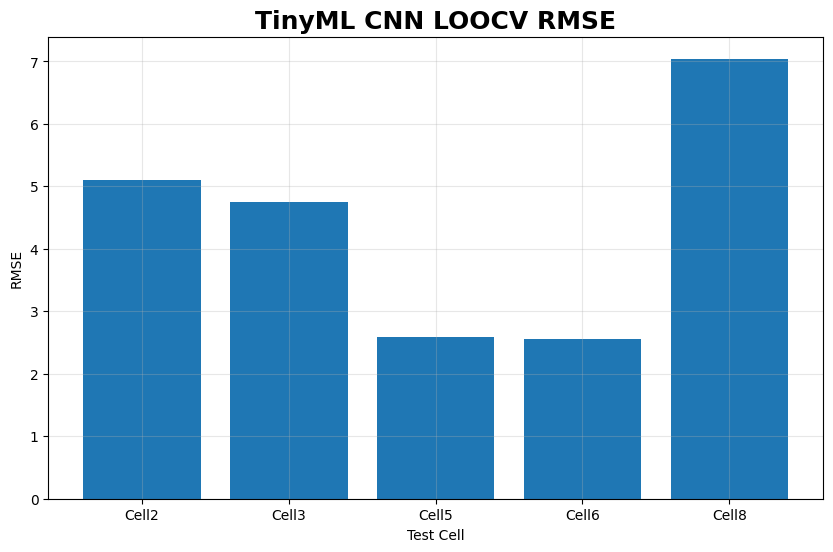


Saved to: /content/drive/MyDrive/TinyML_RUL_20260601_180821


In [29]:
plt.figure(figsize=(10,6))

plt.bar(
    results_df['Test_Cell'][:-1],
    results_df['RMSE'][:-1]
)

plt.title(
    'TinyML CNN LOOCV RMSE',
    fontsize=18,
    fontweight='bold'
)

plt.xlabel('Test Cell')
plt.ylabel('RMSE')

plt.grid(alpha=0.3)

plt.savefig(
    f'{save_dir}/Tiny_RMSE_Barplot.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

print("\nSaved to:", save_dir)